In [1]:
%matplotlib inline

# Gradient Descent-Based Optimization

Below, we explore two parameters in gradient descent-based optimization of neural networks:

* learning rate
* momentum

The goal of this page is to let you "see" these parameters in action to build intuition.

In class, we discussed gradient descent with respect to (w.r.t.) a discrete set of examples (data points). Below, I take it a step further and do it analytically. 

Yes, I know, I could improve algorithm initilization, overall coding, etc. The point of this Jupyter page is to give you a "sand box" to play with.

First, lets declare our libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D

Next, lets define the function we want to optimize and derive its derivative.

I gave you three different functions so you can pick and explore!

In [3]:
# 1, 2, or 3 for which function you want to optimize
WhichFx = 1

if(WhichFx==1):
    
    # this is our fx -> ( z = x^2/10 + (x*y)/50 + y^2 )
    def func_z(x, y):
        z = x**2/10. + x*y/50. + y**2.
        return z

    # this is the derivative w.r.t. x
    def der_x(x, y):
        return (2*x/10. + y/50.)

    # derivative w.r.t. y
    def der_y(x, y):
        return (x/50. + 2*y/1.)
    
    # below, this is the x and y "limits" that we will plot
    # e.g., [-3,3] means x can go from -3 to 3 (same for y)
    bounds = np.asarray([-3,3])
    
elif(WhichFx==2):
    
    def func_z(x, y):
        z = x**2 + 3 * np.sin(y)
        return z

    def der_x(x, y):
        return 2*x

    def der_y(x, y):
        return 3 * np.cos(y)    
    
    bounds = np.asarray([-6,6])
    
if(WhichFx==3):
    
    def func_z(x, y):
        z = x**4 - 2*x**2 + y**2
        return z

    def der_x(x, y):
        return 4*x**3 - 4*x

    def der_y(x, y):
        return 2*y
    
    bounds = np.asarray([-3,3])

Lets define a gradient descent function that just has a learning rate.

Again, note, I am solving this analytically, not w.r.t. a set of data. Wanted to show you another way to look at this problem.

In [4]:
# previous_x = where to start in x domain
# previous_y = where to start in y domain
# learning_rate = user defined parameter
# epoch = how many to run?
def gradient_descentGD(previous_x, previous_y, learning_rate, epoch):
    
    # store our gradients, want to draw these later
    x_gd = []
    y_gd = []
    z_gd = []

    # append the first sampled point (what was passed to this function)
    x_gd.append(previous_x)
    y_gd.append(previous_y)
    z_gd.append(func_z(previous_x, previous_y)) # evaluate its function value!

    # gradient descent algorithm
    for i in range(epoch):

        # what is our derivative?
        dx = der_x(previous_x,previous_y)
        dy = der_y(previous_x,previous_y)
        
        # simple update in x and y
        current_x = previous_x - learning_rate*dx
        x_gd.append(current_x)
        
        current_y = previous_y - learning_rate*dy
        y_gd.append(current_y)

        z_gd.append(func_z(current_x, current_y))

        # update previous_x and previous_y
        previous_x = current_x
        previous_y = current_y

    return x_gd, y_gd, z_gd

Lets pick our init values. I just manually selected these fyi. Pick whatever you like.

In [5]:
if(WhichFx==1):
    # location to start at 
    x0 = 3
    y0 = 2
    # learning rate
    learning_rate = 0.9
    # number of epochs
    epoch = 100
elif(WhichFx==2):
    x0 = 4
    y0 = 1
    learning_rate = 0.2
    epoch = 100
elif(WhichFx==3):
    x0 = -2
    y0 = -2
    learning_rate = 0.15
    epoch = 50   

Run our algorithm

In [6]:
x_gd1, y_gd1, z_gd1 = gradient_descentGD(x0, y0, learning_rate, epoch)

Show the result (plot it)

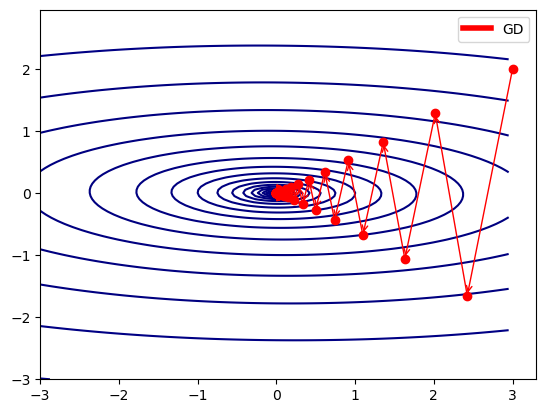

In [7]:
a = np.arange(bounds[0], bounds[1], 0.05)
b = np.arange(bounds[0], bounds[1], 0.05)
x, y = np.meshgrid(a, b)
z = func_z(x, y)
fig1, ax1 = plt.subplots()
ax1.contour(x, y, z, levels=np.logspace(-3, 3, 25), cmap='jet')

# Plot our steps
ax1.plot(x_gd1, y_gd1, 'ro')
for i in range(1, epoch+1):
    ax1.annotate('', xy=(x_gd1[i], y_gd1[i]), xytext=(x_gd1[i-1], y_gd1[i-1]),
                   arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 1},
                   va='center', ha='center')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='r', lw=4, label='GD')]
ax1.legend(handles=legend_elements, loc='upper right')
plt.show()

What if we considered momentum?

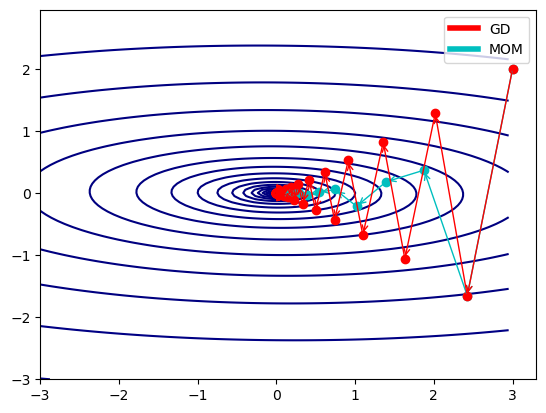

In [8]:
def gradient_descentMOM(previous_x, previous_y, learning_rate, epoch, mom):
    
    x_gd = []
    y_gd = []
    z_gd = []

    x_v = 0
    y_v = 0
    
    x_gd.append(previous_x)
    y_gd.append(previous_y)
    z_gd.append(func_z(previous_x, previous_y))

    for i in range(epoch):
        
        dx = der_x(previous_x,previous_y)
        dy = der_y(previous_x,previous_y)
        
        # note, our update changes a tad
        x_v = mom * x_v - learning_rate*dx # velocity
        current_x = previous_x + x_v # position
        x_gd.append(current_x)
                
        y_v = mom * y_v - learning_rate*dy # velocity
        current_y = previous_y + y_v # position
        y_gd.append(current_y)

        z_gd.append(func_z(current_x, current_y))

        previous_x = current_x
        previous_y = current_y

    return x_gd, y_gd, z_gd

# lets call the learning algorithm
mom = 0.25 
x_gd2, y_gd2, z_gd2 = gradient_descentMOM(x0, y0, learning_rate, epoch, mom)

# now draw the result!

a = np.arange(bounds[0], bounds[1], 0.05)
b = np.arange(bounds[0], bounds[1], 0.05)
x, y = np.meshgrid(a, b)
z = func_z(x, y)
fig1, ax1 = plt.subplots()
ax1.contour(x, y, z, levels=np.logspace(bounds[0], bounds[1], 25), cmap='jet')

# Plot our steps
ax1.plot(x_gd2, y_gd2, 'co')
for i in range(1, epoch+1):
    ax1.annotate('', xy=(x_gd2[i], y_gd2[i]), xytext=(x_gd2[i-1], y_gd2[i-1]),
                   arrowprops={'arrowstyle': '->', 'color': 'c', 'lw': 1},
                   va='center', ha='center')

# Plot our steps
ax1.plot(x_gd1, y_gd1, 'ro')
for i in range(1, epoch+1):
    ax1.annotate('', xy=(x_gd1[i], y_gd1[i]), xytext=(x_gd1[i-1], y_gd1[i-1]),
                   arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 1},
                   va='center', ha='center')
    
legend_elements = [Line2D([0], [0], color='r', lw=4, label='GD'),
                  Line2D([0], [0], color='c', lw=4, label='MOM')]
ax1.legend(handles=legend_elements, loc='upper right')
plt.show()

So, you want to learn more ...

In general, there are MANY ways to train a neural network, e.g.,

 * Stochastic gradient descent (SGD)
 * Conjugate gradient descent (https://en.wikipedia.org/wiki/Conjugate_gradient_method)
 * Newton's (and Quasi) method
 * Evolutionary algorithms
 * MORE MORE MORE ...
 
Just w.r.t. gradient descent, there are many "flavors"

 * Nesterov accelerated gradient (see https://arxiv.org/pdf/1212.0901v2.pdf)
 * Adagrad (http://jmlr.org/papers/v12/duchi11a.html and http://www.jmlr.org/papers/volume12/duchi11a/duchi11a.pdf)
 * Adadelta
 * RMSprop (https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf)
 * Adaptive Moment Estimation (ADAM) (https://arxiv.org/pdf/1412.6980.pdf)
 * AMSGrad
 * ...
 
<img src="http://ruder.io/content/images/2016/09/contours_evaluation_optimizers.gif">

What is a good general web link: http://cs231n.github.io/neural-networks-3/

# Q&A  

**Easy**

1) Can you create another function and run this code on that?

2) Play around with ecpoch and learning rate and see if your intuition matches what happens

**Hard**

3) Can you read about and code up adagrad or RMSprop?